We decided to find the best neighborhood in Pittsburgh by comparing each neigborhood's average daily traffic, median age of death, and ___________.  We decided to use traffic data because it is a good representation of how annoying it is to drive around in an area, so we decided that a low traffic count was good.  We decided to use median age at death because we decided that neighborhoods that allow a person to live longer statistically was better.  We decided to use _______ because _______.

In [218]:
import pandas as pd

traffic_path = 'traffic_final_data.csv'
traffic_data = pd.read_csv(traffic_path)
traffic_data["Rank"] = range(1, len(traffic_data["average_daily_car_traffic"])+1)
traffic_data = traffic_data.rename(columns={"neighborhood":"Neighborhood"})
traffic_data.head(10)

,Neighborhood,average_daily_car_traffic,Rank
0,South Side Flats,115.000000,1
1,Lincoln Place,126.000000,2
2,Lincoln-Lemington-Belmar,195.000000,3
3,Fineview,419.000000,4
4,Allegheny West,477.000000,5
5,New Homestead,666.000000,6
6,Overbrook,777.000000,7
7,Summer Hill,937.000000,8
8,Upper Hill,953.333333,9
9,Central Northside,1189.000000,10


In [219]:
death_data = pd.read_csv('median_age_at_death_submetric.csv')
death_data.head(10)

,Neighborhood,Submetric Score
0,South Shore,1
1,Chateau,2
2,North Shore,3
3,Central Oakland,4
4,East Carnegie,5
5,Allegheny Center,6
6,Swisshelm Park,7
7,New Homestead,8
8,Homewood West,9
9,West End,10


In [220]:
crime_data = pd.read_csv('crime_ranking.csv')
crime_data.tail(10)


,Neighborhood,count
81,Regent Square,10.0
82,Oakwood,9.0
83,Esplen,8.0
84,Summer Hill,7.0
85,East Carnegie,6.0
86,Swisshelm Park,5.0
87,New Homestead,4.0
88,Chartiers,3.0
89,Ridgemont,2.0
90,Saint Clair,1.0


Before we can combine the datasets, we need to make sure the neighborhood names are consistent.  We can compare the neighborhood columns as sets to see where the differences are, and then clean the data based on what we found.

In [221]:
set(traffic_data["Neighborhood"]) - (set(death_data["Neighborhood"]) & set(crime_data["Neighborhood"]))
#St. Clair is Saint Clair in the others

{'Chartiers City',
 'South Side Flats',
 'South Side Slopes',
 'Spring Hill-City View',
 'St. Clair'}

In [222]:
print(sorted(set(death_data["Neighborhood"]) - set(crime_data["Neighborhood"])))
print(sorted(set(crime_data["Neighborhood"]) - set(death_data["Neighborhood"])))

['Chartiers City', 'Crawford Roberts', 'Mount Oliver Neighborhood', 'South Shore', 'Southside Flats', 'Southside Slopes', 'Spring Hill-Cityview', "Troy Hill/Herr'S Island"]
['Chartiers', 'Crawford-Roberts', 'Lincoln–Lemington–Belmar', 'Mount Oliver', 'South Side Flats', 'South Side Slopes', 'Southshore', 'Spring Hill–City View', 'Troy Hill']


In [223]:
def clean_names(df):
    df["Neighborhood"] = df["Neighborhood"].str.lower()
    df["Neighborhood"] = df["Neighborhood"].str.replace(" ", "")
    df["Neighborhood"] = df["Neighborhood"].str.replace("-", "")
    df["Neighborhood"] = df["Neighborhood"].str.replace("–", "")
    df["Neighborhood"] = df["Neighborhood"].str.replace("city", "")
    df["Neighborhood"] = df["Neighborhood"].str.replace("neighborhood", "")
    df["Neighborhood"] = df["Neighborhood"].str.replace("/herr'sisland", "")
    df["Neighborhood"] = df["Neighborhood"].str.replace("st.", "saint")


    return df

traffic_data = clean_names(traffic_data)
death_data = clean_names(death_data)
crime_data = clean_names(crime_data)


In [224]:
set(traffic_data["Neighborhood"]) - (set(death_data["Neighborhood"]) & set(crime_data["Neighborhood"]))

set()

In [225]:
print(sorted(set(death_data["Neighborhood"]) - set(crime_data["Neighborhood"])))
print(sorted(set(crime_data["Neighborhood"]) - set(death_data["Neighborhood"])))

[]
[]


Each of the datasets is ranked based on its own metric, so we can combine the different metrics by adding up the neighborhoods positional rankings (1 meaning they did the best in that metric), and the lower the result the better.  However, traffic data only has 64 out of 90 neighborhoods, so in order to prevent bias towards neiborhoods not scored by traffic data, we set them to 32 (the median ranking of traffic data).

In [ ]:
final_df = {}

#Add Traffic data
for index, row in traffic_data.iterrows():
    final_df[row["Neighborhood"]] = row['Rank']

#Add Crime data
for index, row in crime_data.iterrows():
    if row["Neighborhood"] not in final_df.keys():
        final_df[row["Neighborhood"]] = row['count'] + 32   #If neighborhood not in traffic data, give it median traffic ranking
    final_df[row["Neighborhood"]] += row['count']

#Add Death data
for index, row in death_data.iterrows():
    if row["Neighborhood"] not in final_df.keys():
        final_df[row["Neighborhood"]] = row['Submetric Score']
    final_df[row["Neighborhood"]] += row['Submetric Score']


final_df = pd.Series(final_df)
final_df.sort_values().head()

newhomestead     18.0
summerhill       30.0
ridgemont        47.0
swisshelmpark    49.0
eastcarnegie     49.0
dtype: float64

<Axes: >

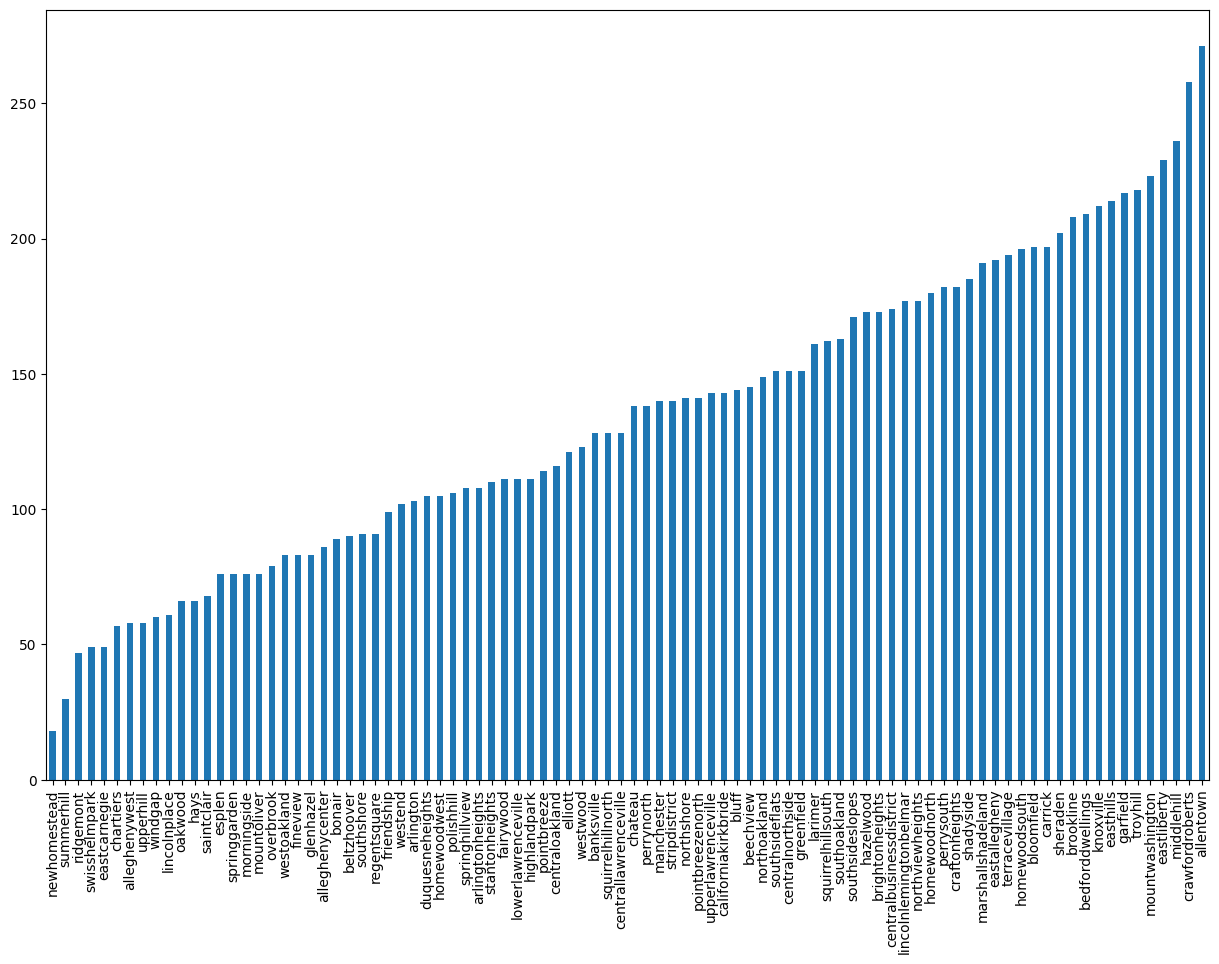

In [227]:
final_df.sort_values(ascending=True).plot(kind='bar', figsize= (15, 10))